# TP2 - Procesamiento puntual

## 0. Importacion de librerias

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Configuracion general de graficos
plt.rcParams['figure.figsize'] = (8, 6)

## 1. Carga de la imagen

Imagen cargada desde: img1.png


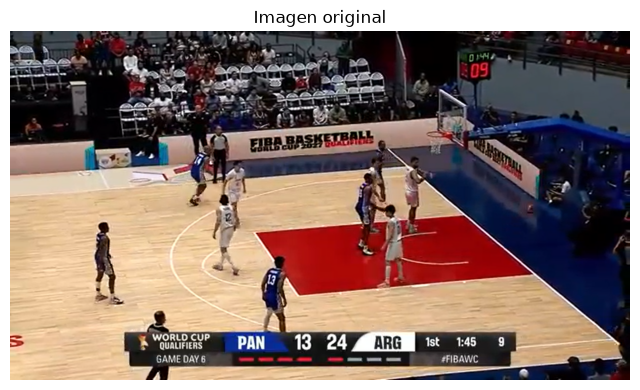

In [3]:
img_path = "img1.png"

img = Image.open(img_path)
print(f"Imagen cargada desde: {img_path}")

plt.imshow(img)
plt.axis("off")
plt.title("Imagen original")
plt.show()

## 2. Técnicas de procesamiento puntual

### 2.0 Pasar a escala de grises

Imagen en escala de grises


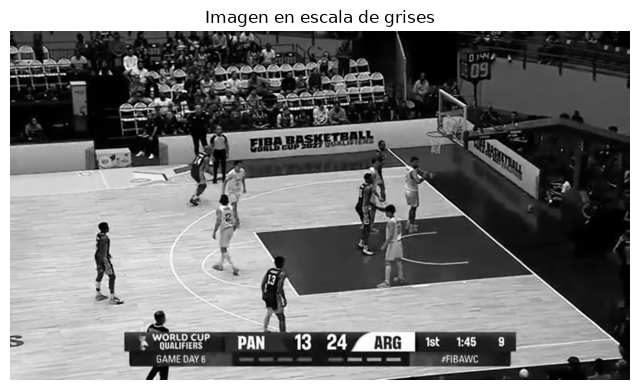

In [17]:
imagen = img.convert("L")

matriz = np.array(imagen)

print(f"Imagen en escala de grises")
plt.imshow(imagen, cmap="gray")
plt.axis("off")
plt.title("Imagen en escala de grises")
plt.show()

### 2.1 Negativo

Tipo de dato: Se obtiene una imagen con la inversa tonal de la imagen de entrada. Ej. Un pixel 0 pasa a 255, y uno 255 pasa a 0.

Utilidad: En nuestro caso, nos permitio identificar las personas que se encuentra en la tribuna del estadio, ademas de delimitar toda la cancha de basquet y el marcador.

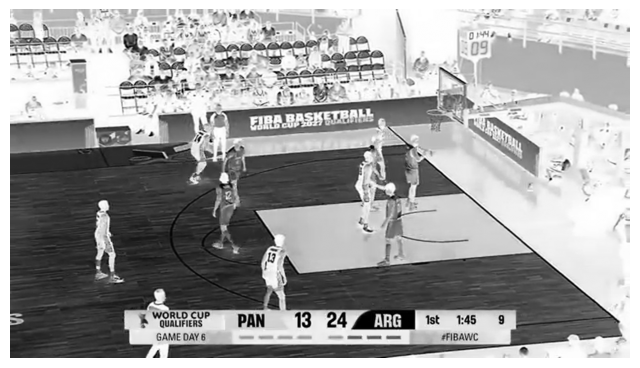

In [5]:
negativo = 255 - matriz

plt.imshow(negativo, cmap="gray")
plt.axis("off")
plt.show()

### 2.2 Operador Umbral

#### 2.2.1 Simple

Tipo de dato: Se obtiene una imagen binaria segun un valor de umbral. Los pixeles que sean mayores al umbral toman el valor 255, y los demas tomaran el valor 0.

Utilidad: Realiza la separacion de los jugadores que estan en la cancha contra la cancha en si. Tambien separa la cancha con el marcador y la tribuna.

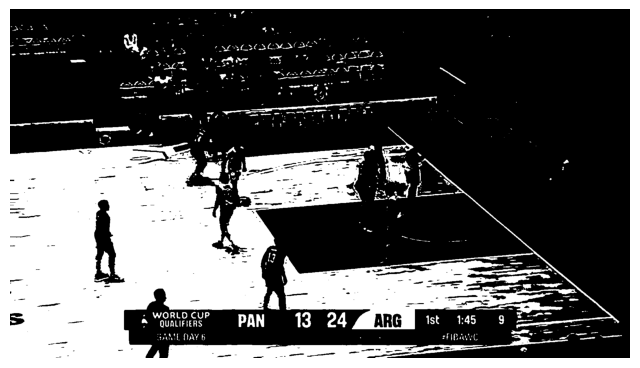

In [6]:
umbral = 180

resultado = np.where(matriz > umbral, 255, 0)

plt.imshow(resultado, cmap="gray")
plt.axis("off")
plt.show()

#### 2.2.2 Binario

Tipo de dato: Nos permite seleccionar un intervalo de niveles de gris, entre p1 y p2. Los que se encuentran dentro del intervalo tomaran el valor 255, sino 0.

Utilidad: Identifica las butacas, aro y el marcador dentro de la cancha. 

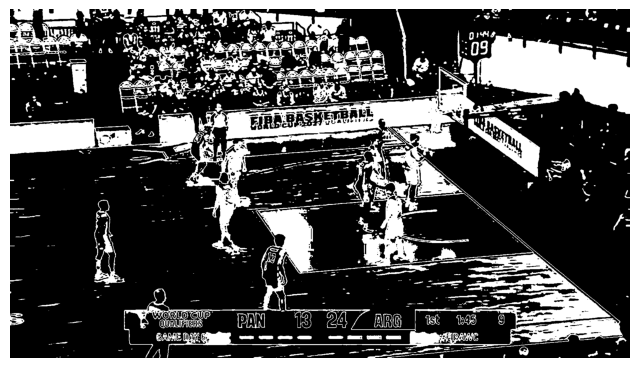

In [7]:
p1 = 60
p2 = 180

umbral_binario = np.where(
    (matriz > p1) & (matriz < p2),
    255,
    0
).astype(np.uint8)

plt.imshow(umbral_binario, cmap="gray")
plt.axis("off")
plt.show()


#### 2.2.3 Escala de grises

Tipo de dato: Trabaja con un intervalo de niveles de gris, entre p1 y p2, pero mantiene los valores originales de los pixeles que se encuentran dentro del intervalo.

Utilidad: Identifica las butacas y carteleria de fondo.

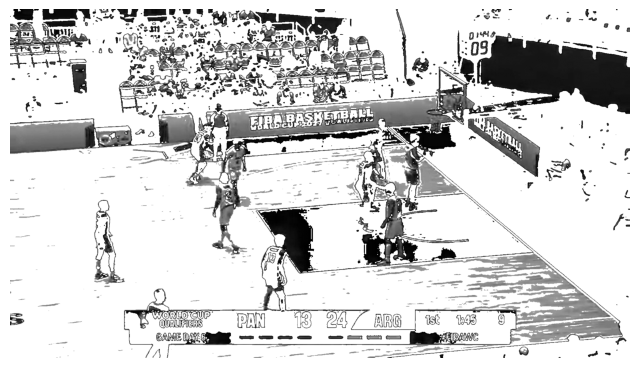

In [8]:
p1 = 60
p2 = 180

umbral_grises = np.where(
    (matriz > p1) & (matriz < p2),
    matriz,
    255
).astype(np.uint8)

plt.imshow(umbral_grises, cmap="gray")
plt.axis("off")
plt.show()

### 2.3 Operador de extension

Tipo de dato: Permite transfomar un determinado intervalo de niveles de gris para utilizar una escala mas amplia. Los valores entre p1 y p2 se llevan a la escala completa, y los valores fuera son suprimidos.

Utilidad: Identifica la zona y la cancha en gneeral, ademas de dar mas detalle a espectadores en la grada.

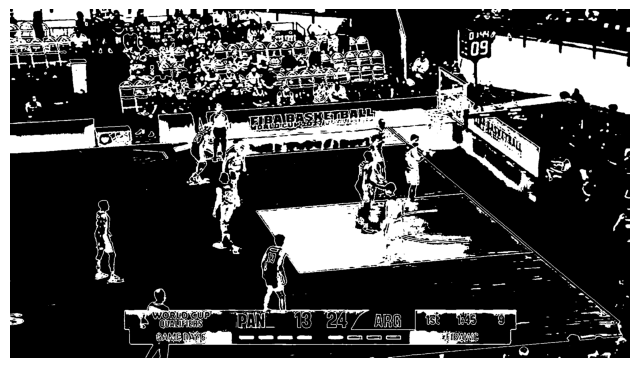

In [9]:
p1 = 50
p2 = 200

extension = np.zeros_like(matriz, dtype=np.float32)

mask = (matriz > p1) & (matriz < p2)

extension[mask] = (
    (matriz[mask] - p1) * 255 / (p2 - p1)
)

extension = np.clip(extension, 0, 255).astype(np.uint8)

plt.imshow(extension, cmap="gray")
plt.axis("off")
plt.show()

### 2.4 Operador de Reduccion de niveles de Gris

Tipo de dato: Produce una imagen con menos niveles de gris que la original. 

Utilidad: Nos permite identificar la informacion que se pierde al reducir la resolucion radiometrica.

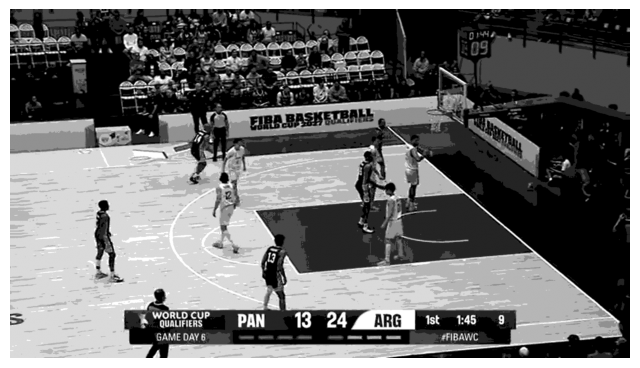

In [10]:
niveles = 8

reduccion = (
    np.floor(matriz / 256 * niveles)
    * (255 / (niveles - 1))
)

reduccion = np.clip(
    reduccion,
    0,
    255
).astype(np.uint8)

plt.imshow(reduccion, cmap="gray")
plt.axis("off")
plt.show()

### 2.5 Operador de rodaja de plano de bits

Tipo de dato: Separar una imagen de 8 bits en 8 planos distintos, desde el bit menos significativo (0) al mas significativo (7)

Utilidad: Nos permite identificar que bits contienen mayor informacion visual. En nuestro caso, del 5 a 7. Del 0 al 4 no es tan detallado lo que informa.

In [11]:
bit = 7

plano = ((matriz >> bit) & 1) * 255

plano = plano.astype(np.uint8)

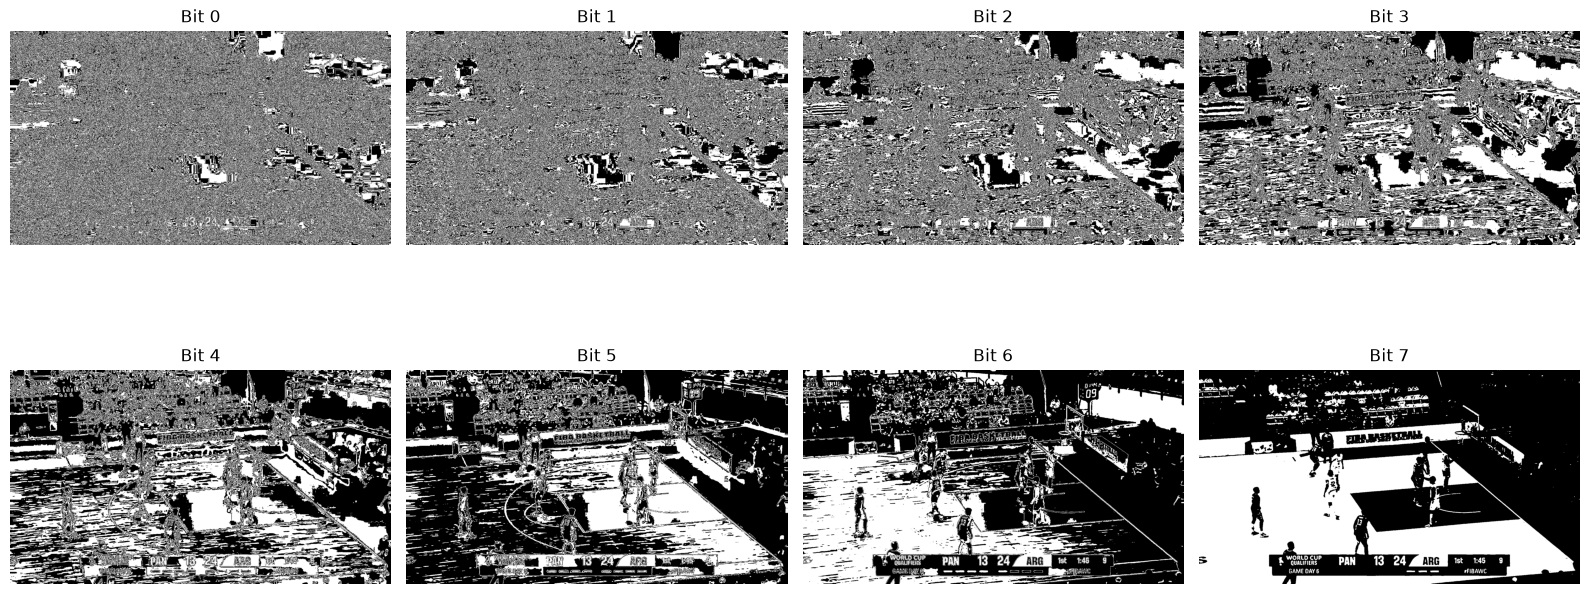

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for bit_actual, ax in enumerate(axes.flat):
  plano = ((matriz >> bit_actual) & 1) * 255
  ax.imshow(plano, cmap="gray")
  ax.set_title(f"Bit {bit_actual}")
  ax.axis("off")

plt.tight_layout()
plt.show()

### 2.6 Operador adición

Tipo de dato: Combina dos imagenes del mismo tamaño digital mediante la suma de sus valores de pixel. El resultado es el promedio de la suma de ambos.

Utilidad: ?

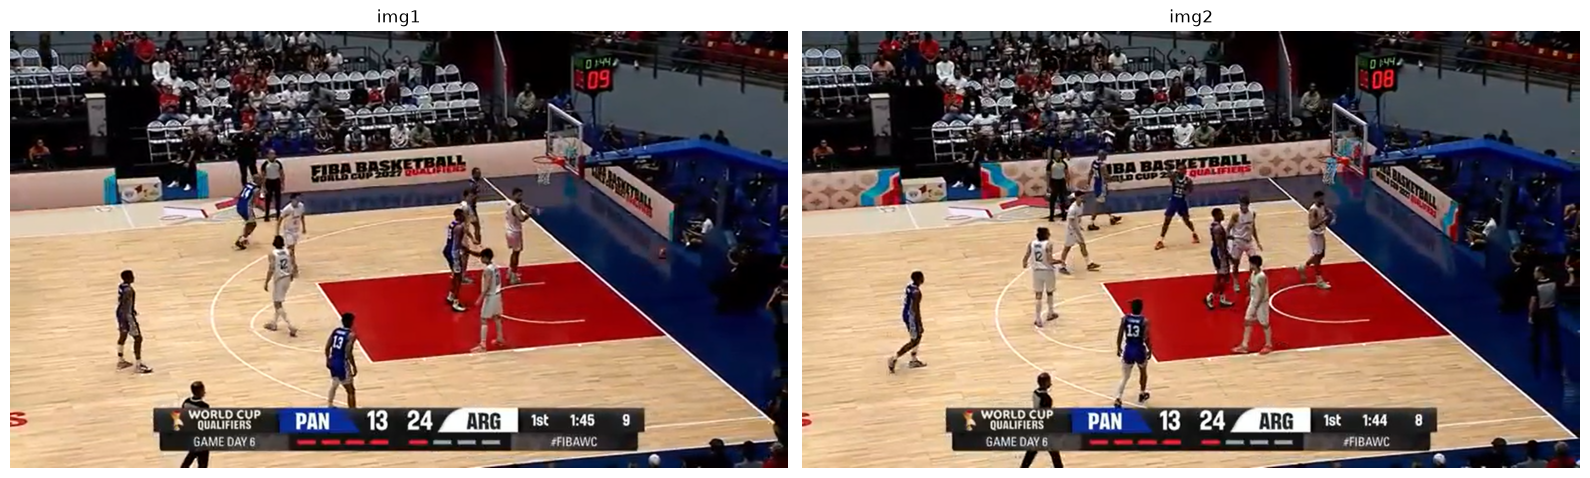

In [13]:
img1 = Image.open("img1.png")
img2 = Image.open("img2.png")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img1)
axes[0].set_title("img1")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("img2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

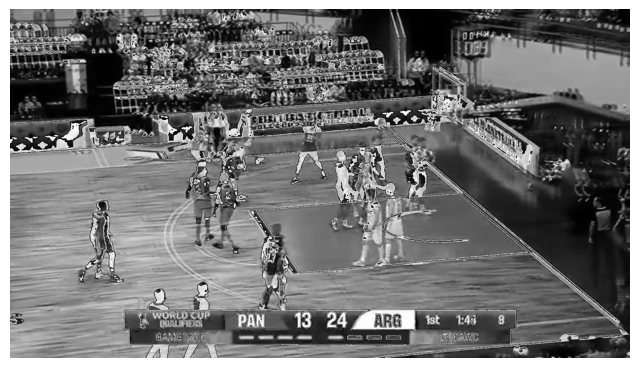

In [14]:
# Escala de grises
img1 = img1.convert("L")
img2 = img2.convert("L")

mimg1 = np.array(img1)
mimg2 = np.array(img2)

adicion = (
    mimg1 +
    mimg2
) / 2

adicion = np.clip(adicion, 0, 255).astype(np.uint8)

plt.imshow(adicion, cmap="gray")
plt.axis("off")
plt.show()

### 2.7 Operador sustraccion

Tipo de dato: Obtiene la diferencia entre dos imagenes. Permite identificar que valores de pixel cambiaron entre una imagen y otra.

Utilidad: El marcador y algunos sectores de la cancha los identifica como que no cambiaron de lugar.

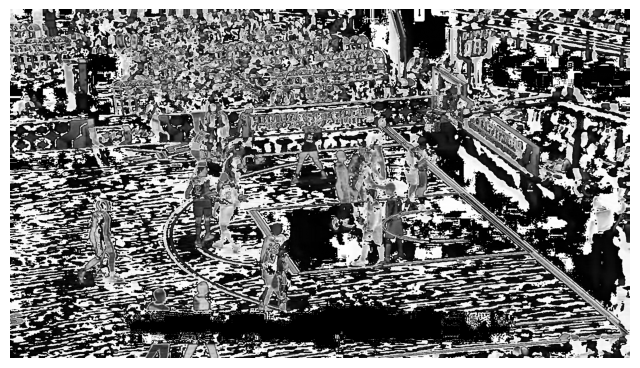

In [15]:
sustraccion = np.abs(
    mimg1 - mimg2
)

sustraccion = np.clip(
    sustraccion,
    0,
    255
).astype(np.uint8)

plt.imshow(sustraccion, cmap="gray")
plt.axis("off")
plt.show()

## 3. Propio operador ( Extension + Umbral )

Objetivo: Deteccion de jugadores en la cancha

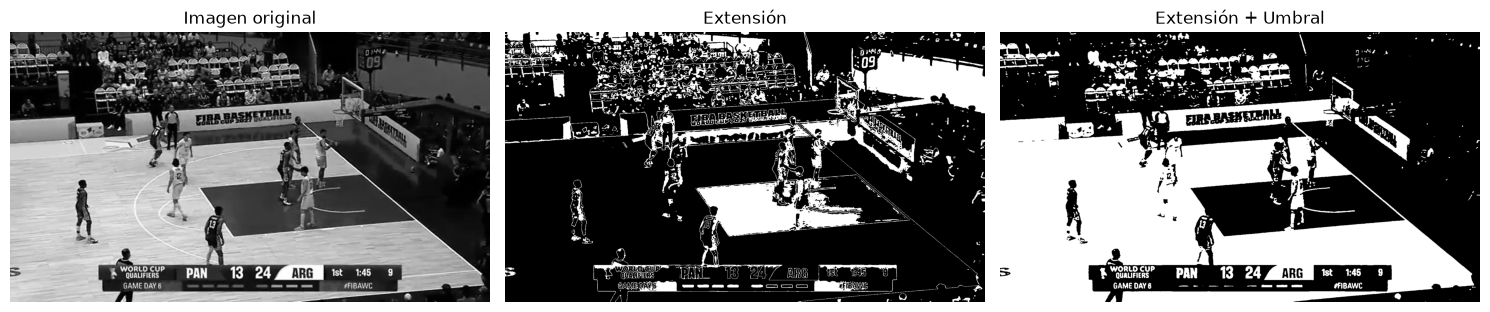

In [16]:
# 1. Extension
p1 = 50
p2 = 230

new_extension = np.zeros_like(matriz, dtype=np.float32)

mask = (matriz > p1) & (matriz < p2)

new_extension[mask] = (
    (matriz[mask] - p1) * 255 / (p2 - p1)
)

new_extension = np.clip(new_extension, 0, 255).astype(np.uint8)

# 2. Umbral
umbral = 100

new_umbral = np.where(matriz > umbral, 255, 0)

# 3. Ver resultado

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(new_extension, cmap="gray")
plt.title("Extensión")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(new_umbral, cmap="gray")
plt.title("Extensión + Umbral")
plt.axis("off")

plt.tight_layout()
plt.show()
